# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |  Alexa Bojorquez |
| **Fecha**      |  2 de octubre |
| **Expediente** |  745497 | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [73]:
import pandas as pd
import numpy as np

In [74]:
data = pd.read_csv('/Users/alevaldivia/Documents/Lab_3/Default.csv')

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [75]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [76]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

In [77]:
data.dtypes

default        str
student        str
balance    float64
income     float64
dtype: object

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [78]:
data['default'] = data['default'].astype('category')
data['student'] = data['student'].astype('category')

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

array([<Axes: title={'center': 'income'}, xlabel='default'>,
       <Axes: title={'center': 'balance'}, xlabel='default'>],
      dtype=object)

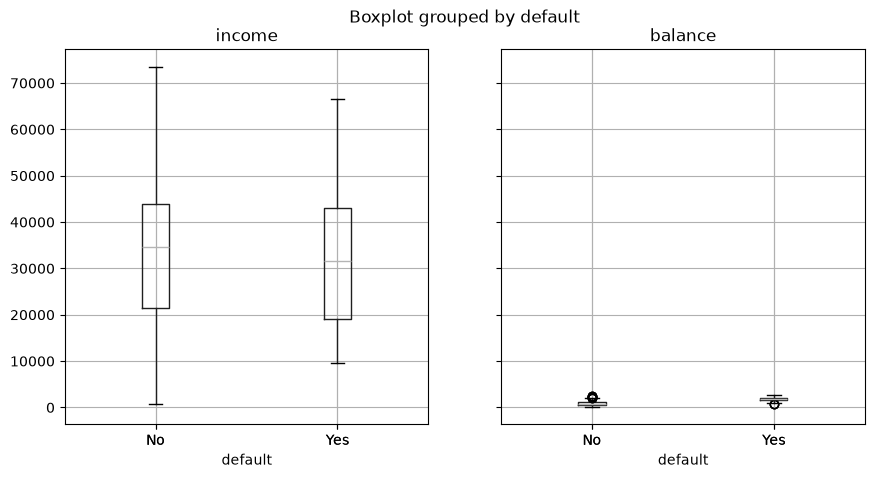

In [79]:
data.boxplot(column=['income', 'balance'], by='default', figsize=(10, 5))

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

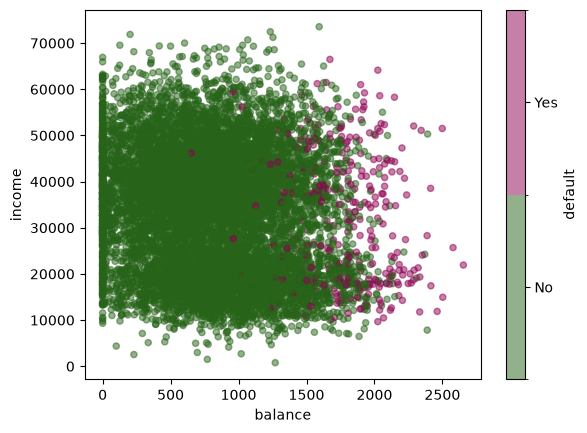

In [80]:
data.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [81]:
y = data['default'] == 'Yes'
X = data['balance']

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

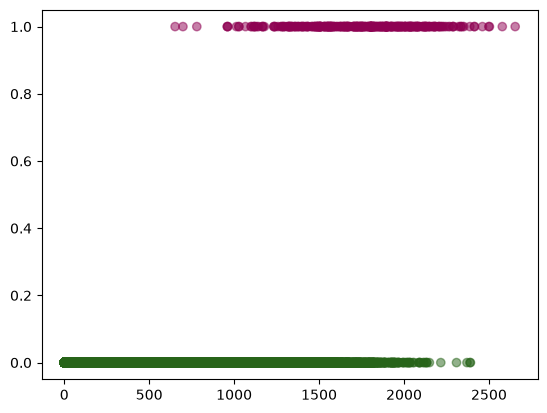

In [82]:
plt.scatter( x=X, y=y, c=y, cmap='PiYG_r', alpha=0.5)

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [83]:
from sklearn.linear_model import LogisticRegression

X = data[['balance']]
y = data['default'] == 'Yes'

lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [84]:
b0 = lr.intercept_[0]
b1 = lr.coef_[0][0]

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [85]:
p = lr.predict_proba(X)[:, 1]
p

array([1.30568146e-03, 2.11259754e-03, 8.59474814e-03, ...,
       2.46651596e-03, 1.16759635e-01, 7.14476480e-05], shape=(10000,))

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [86]:
error = p * (1 - p)
error

array([1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
       2.46043226e-03, 1.03126823e-01, 7.14425432e-05], shape=(10000,))

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [87]:
V = np.diagflat(error)
V

array([[1.30397665e-03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.10813447e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52087844e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.46043226e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.03126823e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 7.14425432e-05]],
      shape=(10000, 10000))

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [88]:
X_cov = np.column_stack((np.ones(len(X)), X))

cov = np.linalg.inv(X_cov.T @ V @ X_cov)
cov

array([[ 1.30442757e-01, -7.81757265e-05],
       [-7.81757265e-05,  4.85656561e-08]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [89]:
se = np.sqrt(np.diag(cov))
se

array([3.61168600e-01, 2.20376169e-04])

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [90]:
beta = np.array([b0, b1])

z = beta / se
z

array([-29.49129089,  24.95240552])

Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

In [91]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z)))
p_value

array([0., 0.])

In [92]:
p_value[1]

np.float64(0.0)

¿Es significativa la relación de los factores con la variable de respuesta?

- Sí es significativa, ya que el p-value de balance es menor a 0.05.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [93]:
X_student = (data['student'] == 'Yes').astype(int).values.reshape(-1, 1)
y = data['default'] == 'Yes'

In [112]:
lr_student = LogisticRegression(max_iter=1000)
lr_student.fit(X_student, y)

b0_s = lr_student.intercept_[0]
b1_s = lr_student.coef_[0][0]

In [113]:
p_s = lr_student.predict_proba(X_student)[:, 1]
p_s

array([0.02923912, 0.04284552, 0.02923912, ..., 0.02923912, 0.02923912,
       0.04284552], shape=(10000,))

In [114]:
error_s = p_s * (1 - p_s)
error_s

array([0.0283842 , 0.04100979, 0.0283842 , ..., 0.0283842 , 0.0283842 ,
       0.04100979], shape=(10000,))

In [115]:
V_s = np.diagflat(error_s)
V_s

array([[0.0283842 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.04100979, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.0283842 , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.0283842 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.0283842 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.04100979]], shape=(10000, 10000))

In [116]:
X_cov_s = np.column_stack((np.ones(len(X_student)), X_student))

cov_s = np.linalg.inv(X_cov_s.T @ V_s @ X_cov_s)
cov_s

array([[ 0.00499304, -0.00499304],
       [-0.00499304,  0.01327579]])

In [117]:
se_s = np.sqrt(np.diag(cov_s))
se_s

array([0.07066143, 0.11522061])

In [118]:
beta_s = np.array([b0_s, b1_s])

z_s= beta_s / se_s
z_s

array([-49.56838058,   3.4386979 ])

In [119]:
from scipy.stats import norm

p_value_s = 2 * (1 - norm.cdf(abs(z_s)))
p_value_s

array([0.        , 0.00058452])

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [120]:
data['student_num'] = (data['student'] == 'Yes').astype(int)

X = data[['balance', 'income', 'student_num']]
y = data['default'] == 'Yes'

In [121]:
lr_multiple = LogisticRegression(max_iter=1000)
lr_multiple.fit(X, y)

lr_multiple.coef_, lr_multiple.intercept_

(array([[ 5.73060606e-03,  3.96189949e-06, -6.12564497e-01]]),
 array([-10.90181161]))

In [122]:
p = lr_multiple.predict_proba(X)[:, 1]
p

array([1.43461036e-03, 1.13105380e-03, 9.71938462e-03, ...,
       2.94476258e-03, 1.46145329e-01, 3.37613242e-05], shape=(10000,))

In [123]:
error = p * (1 - p)
error

array([1.43255226e-03, 1.12977451e-03, 9.62491818e-03, ...,
       2.93609096e-03, 1.24786872e-01, 3.37601844e-05], shape=(10000,))

In [124]:
V = np.diagflat(error)
V

array([[1.43255226e-03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.12977451e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 9.62491818e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.93609096e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.24786872e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 3.37601844e-05]],
      shape=(10000, 10000))

In [125]:
X_cov = np.column_stack((np.ones(len(X)), X))

cov = np.linalg.inv(X_cov.T @ V @ X_cov)
cov

array([[ 2.43205278e-01, -8.22938093e-05, -2.68617514e-06,
        -5.37805378e-02],
       [-8.22938093e-05,  5.36734760e-08, -2.14914824e-11,
        -9.52597217e-06],
       [-2.68617514e-06, -2.14914824e-11,  6.73785374e-11,
         1.51772550e-06],
       [-5.37805378e-02, -9.52597217e-06,  1.51772550e-06,
         5.58820860e-02]])

In [126]:
se = np.sqrt(np.diag(cov))
se

array([4.93158471e-01, 2.31675368e-04, 8.20844306e-06, 2.36393921e-01])

In [127]:
beta = np.concatenate((lr_multiple.intercept_, lr_multiple.coef_[0]))

z_statistic = beta / se
z_statistic

array([-22.10610228,  24.73550002,   0.48266151,  -2.59128701])

In [128]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z_statistic)))
p_value

array([0.        , 0.        , 0.6293361 , 0.00956177])

In [111]:
pd.DataFrame({
    'Variable': ['Intercepto', 'Balance', 'Income', 'Student'],
    'Coeficiente': beta,
    'Error estándar': se,
    'z': z_statistic,
    'p-value': p_value
})

,Variable,Coeficiente,Error estándar,z,p-value
0,Intercepto,-10.901812,0.493158,-22.106102,0.000000
1,Balance,0.005731,0.000232,24.735500,0.000000
2,Income,0.000004,0.000008,0.482662,0.629336
3,Student,-0.612564,0.236394,-2.591287,0.009562


- Balance y Student son significativos porque tienen un p-value menor a 0.05. Income no es significativo ya que su p-value es 0.6293.

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

~ Una prueba de embarazo que salga positiva cuando la persona realmente no está embarazada.

~ Una alarma de seguridad que indique que alguien entró a tu casa cuando en realidad no hay nadie.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

~ Una prueba de embarazo que salga negativa cuando la persona realmente sí está embarazada.

~ Una prueba para detectar cáncer que indique que no hay ningún problema cuando en realidad sí existe.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3